# Create models for prediction of gamma shower for different thresholds of fpr and comparison

## Load modules and data

In [78]:
# lädt geänderte externe Funktionen automatisch
%load_ext autoreload   
%autoreload 2
# import modules
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import pickle

from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline 

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, learning_curve, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.inspection import permutation_importance


from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import roc_curve, make_scorer, confusion_matrix

import optuna 
from optuna.samplers import TPESampler
import time

import sys
from pathlib import Path

project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.features import engineer_features
from src.resample import resampling
#from src.baseline_model import baseline

import src.baseline_model as bm
import log_reg as lr
import support_vector_machine as svm
import random_forest as rf
import neural_network as nn

#print("Geladene Datei:")
#print(bm.__file__)

#print("\nBaseline vorhanden:")
#print(hasattr(bm, "baseline"))

#print("\nNamen im Modul:")
#print(dir(bm))



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
# ignore Data Conversion Warnings
from sklearn.exceptions import DataConversionWarning
import warnings
warnings.filterwarnings(action='ignore', category=DataConversionWarning)

In [3]:
# show three digits
pd.set_option('display.float_format', '{:,.3f}'.format)
pd.set_option('display.precision', 3)
np.set_printoptions(precision=3)

In [4]:
# set column names
columns = [
    "fLength",
    "fWidth",
    "fSize",
    "fConc",
    "fConc1",
    "fAsym",
    "fM3Long",
    "fM3Trans",
    "fAlpha",
    "fDist",
    "class"
]

# load data
df = pd.read_csv(
    r"../data/raw/magic04.data",
    header=None,
    names=columns
)

# remove dublicates before train-test-split
df = df.drop_duplicates().reset_index(drop=True)

# convert target from g/h --> 1/0
df["class"] = df["class"].map({
    "g": 1,   # gamma = signal
    "h": 0    # hadron = background
})

features = df.iloc[:, :-1]
target = df.iloc[:, -1]

features_train, features_test, target_train, target_test = train_test_split(features, target, test_size=0.1, random_state=42)

In [5]:
display(target_train)

15421    0
6829     1
11808    1
7765     1
12077    1
        ..
11284    1
11964    1
5390     1
860      1
15795    0
Name: class, Length: 17014, dtype: int64

In [6]:
# save features_test as 'features_test.csv'
features_train.to_csv(r'../data/raw/features_train_unprocessed.csv', index=False)

In [7]:
# save target_train as 'target_train.csv'
target_train.to_csv(r'../data/raw/target_train_unprocessed.csv', index=False)

In [8]:
# save features_test as 'features_test.csv'
features_test.to_csv(r'../data/raw/features_test_unprocessed.csv', index=False)

In [9]:
# save target_test as 'target_test.csv'
target_test.to_csv(r'../data/raw/target_test_unprocessed.csv', index=False)

## Scoring
Bei dem gegebenen Datensatz ist die accuracy als Gütemaß nicht aussagekräftig. Eine Klassifizierung eines Backround-Events als Gamma-Event ist hier viel schwerwiegender als eine fälschliche Klassifizierung eines Gamma-Events als Backround-Events.
Hier kommt es besonders darauf an, für verschiedene Grenzwerte 0.01, 0.02, 0.05, 0.1 und 0.2 (je nach Experiment) für die Wahrscheinlichkeit ein Backround-Event als Signal zu klassifizieren einen möglichst hohen Wert bei der ROC-Curve zu erhalten. Sieht man ein Gamma-Ereignis als Klasse  1 und ein Backround-Event als Klasse 0 an, so ergibt FPR (False Positiv Rate) den Anteil der Hadron-Ereignisse an, die fälschlicherweise als Gamma klassifiziert werden und TRP (True Positiv Rate / Recall) den Anteil der Gamma-Ereignisse, die korrekt als Gama identifiziert werden. Für die jeweiligen Grenzwerte der FPR, soll also die TPR (also die gamma-Effiezienz) möglichst groß werden. 
Für dieses Projekt wird deshalb ein eigenes Scoring definiert.
Als primäre Auswahlmetrik wird hier 5% verwendet, die anderen Metriken werden jedoch zusätzlich betrachtet

In [10]:
# true positiv rate at a given false positive rate, 0.05 as default
def tpr_at_fpr(target, target_pred, max_fpr=0.05):
    fpr, tpr, _ = roc_curve(target, target_pred)

    return np.max(tpr[fpr <= max_fpr])

In [11]:
# define scorer for different thresholds of fpr
scoring = {
    "roc_auc": "roc_auc",

    "tpr_fpr_001": make_scorer(
        tpr_at_fpr,
        response_method=("decision_function", "predict_proba"),   # use continouus model-score, if decision_function not supportet, use predict_proba
        max_fpr=0.01
    ),

    "tpr_fpr_002": make_scorer(
        tpr_at_fpr,
        response_method=("decision_function", "predict_proba"),
        max_fpr=0.02
    ),

    "tpr_fpr_005": make_scorer(
        tpr_at_fpr,
        response_method=("decision_function", "predict_proba"),
        max_fpr=0.05
    ),

    "tpr_fpr_010": make_scorer(
        tpr_at_fpr,
        response_method=("decision_function", "predict_proba"),
        max_fpr=0.10
    ),

    "tpr_fpr_020": make_scorer(
        tpr_at_fpr,
        response_method=("decision_function", "predict_proba"),
        max_fpr=0.20
    )
}


In diesem Notebook wird zunächst nur der scorer "tpr_fpr_020" verwendet

## Data Preparation

### Datatype transformation

Es ist keine weitere Umwandlung der Trainingsdaten notwendig (Umwandlung Target g/h --> 1/0 siehe oben)

### Data Imputation

Der Datensatz beinhaltet keine fehlenden Werte, es müssen also keine Daten imputiert werden

### Outlier
Der verwendete Datensatz beinhaltet keine unplausiblen Ausreißer. Alle in der univariaten Betrachtung auftretenden extremen Werte werden im Datensatz belassen, da sie in der multivariaten Betrachtung nicht auffällig sind

### Clean_data function

In [12]:
def clean_data(target):
    """
    Input: target to be changed to classes 1/0
    Output: cleaned target
    """
    # convert target from g/h --> 1/0
    target = target.map({
    "g": 1,   # gamma = signal
    "h": 0    # hadron = background
    })
  
    
    return target

### set cross-validation-parameter
Im folgenden wird immer wieder auf diese Definition zurückgegriffen

In [13]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


## Resampling
Für alle threshold-Werte des Scorers werden anhand der logistischen Regression die verschiedenen Resampling-Methoden gegenübergestellt, da die Zielklassen mit etwa 65% (g) zu 35% (h) leicht unausgegleichen sind

In [14]:
## Schleife über alle Threshols
threshold_list = ["tpr_fpr_001", "tpr_fpr_002", "tpr_fpr_005", "tpr_fpr_010", "tpr_fpr_020"]
for threshold in threshold_list:
    # resampling
    resampling(features_train, target_train, threshold, cv, scoring)
    


threshold:  tpr_fpr_001
baseline
make_scorer(tpr_at_fpr, response_method=('decision_function', 'predict_proba'), max_fpr=0.01) on Validationset: 0.060
LogisticRegression(C=0.01, max_iter=1000, random_state=42)
###########
oversampling
make_scorer(tpr_at_fpr, response_method=('decision_function', 'predict_proba'), max_fpr=0.01) on Validationset: 0.078
LogisticRegression(C=0.01, max_iter=1000, random_state=42)
###########
undersampling
make_scorer(tpr_at_fpr, response_method=('decision_function', 'predict_proba'), max_fpr=0.01) on Validationset: 0.077
LogisticRegression(C=0.01, max_iter=1000, random_state=42)
###########
class_weights
make_scorer(tpr_at_fpr, response_method=('decision_function', 'predict_proba'), max_fpr=0.01) on Validationset: 0.077
LogisticRegression(C=0.01, class_weight='balanced', max_iter=1000,
                   random_state=42)
###########
SMOTE
make_scorer(tpr_at_fpr, response_method=('decision_function', 'predict_proba'), max_fpr=0.01) on Validationset: 0.079
Lo

Für alle Verfahren (baseline ausgenommen), zeigt sich ein sehr ähnlicher Score. Der Einfachheit halber wird deshalb class_weights='balanced' verwendet
 

## Baseline model
Als Baseline Modell wird eine einfache logistische Regression mit allen 10 ursprünglichen Features und ohne Sampling verwendet

In [15]:
#threshold_list = ["tpr_fpr_001", "tpr_fpr_002", "tpr_fpr_005", "tpr_fpr_010", "tpr_fpr_020"]

In [ ]:
thresholds = []
model_names = []
files = []
cv_scores = []


for threshold in threshold_list:
    thresholds, model_names, files, cv_scores baseline_features= bm.baseline(features_train, target_train, threshold, cv, scoring, thresholds, model_names, files, cv_scores)

treshold:  tpr_fpr_001
CV mean Score: 0.054
treshold:  tpr_fpr_002
CV mean Score: 0.124
treshold:  tpr_fpr_005
CV mean Score: 0.301
treshold:  tpr_fpr_010
CV mean Score: 0.494
treshold:  tpr_fpr_020
CV mean Score: 0.721


In [17]:
print(thresholds)
print(model_names)
print(files)
print(cv_scores)

['tpr_fpr_001', 'tpr_fpr_002', 'tpr_fpr_005', 'tpr_fpr_010', 'tpr_fpr_020']
['logistische Regression Baseline', 'logistische Regression Baseline', 'logistische Regression Baseline', 'logistische Regression Baseline', 'logistische Regression Baseline']
[WindowsPath('../models/log_reg_bl_tpr_fpr_001.p'), WindowsPath('../models/log_reg_bl_tpr_fpr_002.p'), WindowsPath('../models/log_reg_bl_tpr_fpr_005.p'), WindowsPath('../models/log_reg_bl_tpr_fpr_010.p'), WindowsPath('../models/log_reg_bl_tpr_fpr_020.p')]
[np.float64(0.0540277665508043), np.float64(0.12441718535284133), np.float64(0.30106070649098704), np.float64(0.4942458572467868), np.float64(0.7212340958693719)]


## Feature Engineering
Wie in der EDA bereits vorgestellt, gibt es einige inteessante neue Features, die aus den alten Features erstellt werden können

In [18]:
features_train_eng = engineer_features(features_train)

In [19]:
features_train_eng

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,abs_fAsym,abs_fM3Long,abs_fM3Trans,width_length_ratio,ellipse_area,brightest_pixel_share,alpha_alignment
15421,73.430,29.869,2.920,0.244,0.116,-29.789,-73.952,21.969,6.050,190.817,29.789,73.952,21.969,0.407,"6,890.538",0.476,0.994
6829,12.627,11.792,2.051,0.702,0.378,15.930,-9.319,9.454,37.228,220.666,15.930,9.319,9.454,0.934,467.802,0.538,0.796
11808,21.912,12.507,2.233,0.620,0.389,13.819,15.595,-10.103,72.975,63.185,13.819,15.595,10.103,0.571,860.964,0.627,0.293
7765,25.187,16.603,2.545,0.485,0.298,14.022,-12.789,9.889,3.873,194.373,14.022,12.789,9.889,0.659,"1,313.706",0.615,0.998
12077,58.916,14.646,2.947,0.251,0.131,-13.845,44.502,4.259,1.283,242.224,13.845,44.502,4.259,0.249,"2,710.723",0.520,1.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,31.921,16.767,2.657,0.384,0.235,3.791,21.017,3.435,3.045,249.375,3.791,21.017,3.435,0.525,"1,681.422",0.612,0.999
11964,43.454,17.654,2.997,0.262,0.143,-12.485,-23.286,-11.357,6.261,184.729,12.485,23.286,11.357,0.406,"2,410.034",0.544,0.994
5390,19.993,12.087,2.435,0.573,0.398,16.141,16.324,9.437,12.772,193.893,16.141,16.324,9.437,0.605,759.142,0.696,0.975
860,31.434,23.265,2.934,0.296,0.172,-9.128,19.852,19.289,79.959,23.236,9.128,19.852,19.289,0.740,"2,297.465",0.581,0.174


In [20]:
features_train_eng.shape

(17014, 17)

## Logistische Regression
Als erstes Modell wird die logistische Regression betrachtet, zunächst ohne PCA, dann mit PCA. Im Anschluss wird mittels Bayesian Optimization eine Optimierung der Hyperparameter vorgenommen

In [22]:
for threshold in threshold_list:
    thresholds, model_names, files, cv_scores = lr.logistic_regression(features_train_eng, target_train, threshold, cv, scoring, thresholds, model_names, files, cv_scores)

treshold:  tpr_fpr_001
CV mean Score: 0.052


c:\Users\moonp\Documents\Beruflich\Weiterbildung\Stackfuel - Data Science\Portfolio Projekt\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1435: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


treshold:  tpr_fpr_002
CV mean Score: 0.116


c:\Users\moonp\Documents\Beruflich\Weiterbildung\Stackfuel - Data Science\Portfolio Projekt\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1435: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


treshold:  tpr_fpr_005
CV mean Score: 0.311


c:\Users\moonp\Documents\Beruflich\Weiterbildung\Stackfuel - Data Science\Portfolio Projekt\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1435: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


treshold:  tpr_fpr_010
CV mean Score: 0.550


c:\Users\moonp\Documents\Beruflich\Weiterbildung\Stackfuel - Data Science\Portfolio Projekt\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1435: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


treshold:  tpr_fpr_020
CV mean Score: 0.768


c:\Users\moonp\Documents\Beruflich\Weiterbildung\Stackfuel - Data Science\Portfolio Projekt\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1435: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


zum Vergleich Ergebnis des Baseline Modells: 0.721
Durch Hinzunahme der neu erstellten Features deutliche Verbesserung der Modellgüte



### logistische Regression mit PCA

In [23]:
# build unoptimized model with PCA
for threshold in threshold_list:
    thresholds, model_names, files, cv_scores = lr.logistic_regression_pca(features_train_eng, target_train, threshold, cv, scoring, thresholds, model_names, files, cv_scores)

treshold:  tpr_fpr_001
CV mean Score: 0.057


c:\Users\moonp\Documents\Beruflich\Weiterbildung\Stackfuel - Data Science\Portfolio Projekt\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1435: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


treshold:  tpr_fpr_002
CV mean Score: 0.124


c:\Users\moonp\Documents\Beruflich\Weiterbildung\Stackfuel - Data Science\Portfolio Projekt\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1435: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


treshold:  tpr_fpr_005
CV mean Score: 0.273


c:\Users\moonp\Documents\Beruflich\Weiterbildung\Stackfuel - Data Science\Portfolio Projekt\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1435: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


treshold:  tpr_fpr_010
CV mean Score: 0.491


c:\Users\moonp\Documents\Beruflich\Weiterbildung\Stackfuel - Data Science\Portfolio Projekt\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1435: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


treshold:  tpr_fpr_020
CV mean Score: 0.717


c:\Users\moonp\Documents\Beruflich\Weiterbildung\Stackfuel - Data Science\Portfolio Projekt\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1435: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


zum Vergleich ohne PCA: 0.768
Durch Hinzunahme der PCA deutliche Verschlechterung der Modellgüte 

### logistische Regression mit optuna-Optimierung

In [24]:
# build optimized model
for threshold in threshold_list:
    thresholds, model_names, files, cv_scores = lr.logistic_regression_opt(features_train_eng, target_train, threshold, cv, scoring, thresholds, model_names, files, cv_scores)

[I 2026-09-29 19:21:16,413] A new study created in memory with name: no-name-212466b6-368b-4c13-8158-38f7fb9af21c
[I 2026-09-29 19:21:16,692] Trial 0 finished with value: 0.05250040417104518 and parameters: {'C': 0.041858227295469716, 'l1_ratio': 0.0, 'n_components': 11}. Best is trial 0 with value: 0.05250040417104518.
[I 2026-09-29 19:21:16,978] Trial 1 finished with value: 0.05375806321235146 and parameters: {'C': 0.0012363188277052211, 'l1_ratio': 0.0, 'n_components': 15}. Best is trial 1 with value: 0.05375806321235146.
[I 2026-09-29 19:21:17,309] Trial 2 finished with value: 0.05186933150109126 and parameters: {'C': 1.6136341713591311, 'l1_ratio': 0.0, 'n_components': 17}. Best is trial 1 with value: 0.05375806321235146.
[I 2026-09-29 19:21:17,550] Trial 3 finished with value: 0.07416417427855468 and parameters: {'C': 67.1581131106993, 'l1_ratio': 0.0, 'n_components': 4}. Best is trial 3 with value: 0.07416417427855468.
[I 2026-09-29 19:21:17,754] Trial 4 finished with value: 0.0

threshold:  tpr_fpr_001
results:     Number of iterations  Iteration Number of Optimal Hyperparamters  Score  \
0                    50                                          45  0.132   

   Time Elapsed (s)  
0            12.707  
best params:  {'C': 0.0002559440117818792, 'l1_ratio': 1.0, 'n_components': 7}


c:\Users\moonp\Documents\Beruflich\Weiterbildung\Stackfuel - Data Science\Portfolio Projekt\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1435: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
[I 2026-09-29 19:21:29,480] A new study created in memory with name: no-name-1c475d6b-3e84-4ab8-9e29-98c6bc7edb2a


CV Score: 0.132


[I 2026-09-29 19:21:29,722] Trial 0 finished with value: 0.1168653302077439 and parameters: {'C': 0.041858227295469716, 'l1_ratio': 0.0, 'n_components': 11}. Best is trial 0 with value: 0.1168653302077439.
[I 2026-09-29 19:21:29,988] Trial 1 finished with value: 0.1207312262549511 and parameters: {'C': 0.0012363188277052211, 'l1_ratio': 0.0, 'n_components': 15}. Best is trial 1 with value: 0.1207312262549511.
[I 2026-09-29 19:21:30,362] Trial 2 finished with value: 0.11614590574731225 and parameters: {'C': 1.6136341713591311, 'l1_ratio': 0.0, 'n_components': 17}. Best is trial 1 with value: 0.1207312262549511.
[I 2026-09-29 19:21:30,580] Trial 3 finished with value: 0.14320362137256487 and parameters: {'C': 67.1581131106993, 'l1_ratio': 0.0, 'n_components': 4}. Best is trial 3 with value: 0.14320362137256487.
[I 2026-09-29 19:21:30,792] Trial 4 finished with value: 0.14392308625010103 and parameters: {'C': 0.013480180290890806, 'l1_ratio': 0.0, 'n_components': 5}. Best is trial 4 with 

...

c:\Users\moonp\Documents\Beruflich\Weiterbildung\Stackfuel - Data Science\Portfolio Projekt\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1435: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
[I 2026-09-29 19:22:10,019] A new study created in memory with name: no-name-b27ea0b8-2bbc-408d-b44b-4547e6133891


CV Score: 0.552


[I 2026-09-29 19:22:10,225] Trial 0 finished with value: 0.7188974618058361 and parameters: {'C': 0.041858227295469716, 'l1_ratio': 0.0, 'n_components': 11}. Best is trial 0 with value: 0.7188974618058361.
[I 2026-09-29 19:22:10,493] Trial 1 finished with value: 0.7275275240481771 and parameters: {'C': 0.0012363188277052211, 'l1_ratio': 0.0, 'n_components': 15}. Best is trial 1 with value: 0.7275275240481771.
[I 2026-09-29 19:22:10,839] Trial 2 finished with value: 0.7678010670115593 and parameters: {'C': 1.6136341713591311, 'l1_ratio': 0.0, 'n_components': 17}. Best is trial 2 with value: 0.7678010670115593.
[I 2026-09-29 19:22:11,084] Trial 3 finished with value: 0.701546681755719 and parameters: {'C': 67.1581131106993, 'l1_ratio': 0.0, 'n_components': 4}. Best is trial 2 with value: 0.7678010670115593.
[I 2026-09-29 19:22:11,324] Trial 4 finished with value: 0.7026252121897987 and parameters: {'C': 0.013480180290890806, 'l1_ratio': 0.0, 'n_components': 5}. Best is trial 2 with value

threshold:  tpr_fpr_020
results:     Number of iterations  Iteration Number of Optimal Hyperparamters  Score  \
0                    50                                          27  0.769   

   Time Elapsed (s)  
0            14.301  
best params:  {'C': 859.9521126161015, 'l1_ratio': 0.0, 'n_components': 16}
CV Score: 0.769


c:\Users\moonp\Documents\Beruflich\Weiterbildung\Stackfuel - Data Science\Portfolio Projekt\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1435: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


In [25]:
print(thresholds)
print(model_names)
print(files)
print(cv_scores)

['tpr_fpr_001', 'tpr_fpr_002', 'tpr_fpr_005', 'tpr_fpr_010', 'tpr_fpr_020', 'tpr_fpr_001', 'tpr_fpr_002', 'tpr_fpr_005', 'tpr_fpr_010', 'tpr_fpr_020', 'tpr_fpr_001', 'tpr_fpr_002', 'tpr_fpr_005', 'tpr_fpr_010', 'tpr_fpr_020', 'tpr_fpr_001', 'tpr_fpr_002', 'tpr_fpr_005', 'tpr_fpr_010', 'tpr_fpr_020']
['logistische Regression Baseline', 'logistische Regression Baseline', 'logistische Regression Baseline', 'logistische Regression Baseline', 'logistische Regression Baseline', 'logistische Regression simple', 'logistische Regression simple', 'logistische Regression simple', 'logistische Regression simple', 'logistische Regression simple', 'logistische Regression PCA', 'logistische Regression PCA', 'logistische Regression PCA', 'logistische Regression PCA', 'logistische Regression PCA', 'Logistische Regression optimiert', 'Logistische Regression optimiert', 'Logistische Regression optimiert', 'Logistische Regression optimiert', 'Logistische Regression optimiert']
[WindowsPath('../models/log_

## Support Vektor Machine
In EDA mehrere nichtlineare Zusammenhänge entdeckt, deshalb SVM besonders interessant

In [26]:
for threshold in threshold_list:
    thresholds, model_names, files, cv_scores = svm.support_vector_machine(features_train_eng, target_train, threshold, cv, scoring, thresholds, model_names, files, cv_scores)

CV Score: 0.177
treshold:  tpr_fpr_001
CV mean Score: 0.177
CV Score: 0.309
treshold:  tpr_fpr_002
CV mean Score: 0.309
CV Score: 0.535
treshold:  tpr_fpr_005
CV mean Score: 0.535
CV Score: 0.750
treshold:  tpr_fpr_010
CV mean Score: 0.750
CV Score: 0.907
treshold:  tpr_fpr_020
CV mean Score: 0.907


### optimierte Support Vector Machine

In [27]:
# build optimized model
for threshold in threshold_list:
    thresholds, model_names, files, cv_scores = svm.support_vector_machine_opt(features_train_eng, target_train, threshold, cv, scoring, thresholds, model_names, files, cv_scores)

[I 2026-09-29 19:23:19,506] A new study created in memory with name: no-name-acfd8144-dff0-4375-866d-743e8a7fbb26
[I 2026-09-29 19:23:37,880] Trial 0 finished with value: 0.14482273057958128 and parameters: {'C': 0.1767016940294795, 'gamma': 5.669849511478847, 'n_components': 13}. Best is trial 0 with value: 0.14482273057958128.


CV fertig: 0.1448


[I 2026-09-29 19:23:45,297] Trial 1 finished with value: 0.05645550076792498 and parameters: {'C': 3.907967156822881, 'gamma': 0.0006026889128682511, 'n_components': 3}. Best is trial 0 with value: 0.14482273057958128.


CV fertig: 0.0565


[I 2026-09-29 19:23:57,221] Trial 2 finished with value: 0.1274708996847466 and parameters: {'C': 0.002231010801867922, 'gamma': 2.1423021757741068, 'n_components': 11}. Best is trial 0 with value: 0.14482273057958128.


...

[I 2026-09-29 20:37:28,059] Trial 48 finished with value: 0.8472670358095546 and parameters: {'C': 31.125442360265122, 'gamma': 0.5547469927348738, 'n_components': 17}. Best is trial 40 with value: 0.9157685312424219.


CV fertig: 0.8473


[I 2026-09-29 20:37:39,598] Trial 49 finished with value: 0.9014756284859754 and parameters: {'C': 0.5930817921680726, 'gamma': 0.03905072959094763, 'n_components': 16}. Best is trial 40 with value: 0.9157685312424219.


CV fertig: 0.9015
threshold:  tpr_fpr_020
results:     Number of iterations  Iteration Number of Optimal Hyperparamters  Score  \
0                    50                                          40  0.916   

   Time Elapsed (s)  
0           712.049  
best params:  {'C': 17.033881600712867, 'gamma': 0.04402725017995011, 'n_components': 16}
CV Score: 0.916


c:\Users\moonp\Documents\Beruflich\Weiterbildung\Stackfuel - Data Science\Portfolio Projekt\.venv\Lib\site-packages\sklearn\svm\_base.py:337: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


## Random Forrest

In [28]:
for threshold in threshold_list:
    thresholds, model_names, files, cv_scores = rf.random_forest(features_train_eng, target_train, threshold, cv, scoring, thresholds, model_names, files, cv_scores)

treshold:  tpr_fpr_001
CV mean Score: 0.325
treshold:  tpr_fpr_002
CV mean Score: 0.431
treshold:  tpr_fpr_005
CV mean Score: 0.614
treshold:  tpr_fpr_010
CV mean Score: 0.782
treshold:  tpr_fpr_020
CV mean Score: 0.917


### optimierter Random Forest

In [29]:
# build optimized model
for threshold in threshold_list:
    thresholds, model_names, files, cv_scores = rf.random_forest_opt(features_train_eng, target_train, threshold, cv, scoring, thresholds, model_names, files, cv_scores)

[I 2026-09-29 20:38:54,403] A new study created in memory with name: no-name-80dd74f7-e8d0-442e-b206-413584218a23
[I 2026-09-29 20:39:01,791] Trial 0 finished with value: 0.330728720394471 and parameters: {'n_estimators': 100, 'max_depth': 15, 'min_samples_split': 8, 'min_samples_leaf': 7, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.330728720394471.
[I 2026-09-29 20:39:05,682] Trial 1 finished with value: 0.3298284293913184 and parameters: {'n_estimators': 50, 'max_depth': 14, 'min_samples_split': 8, 'min_samples_leaf': 8, 'max_features': 'log2'}. Best is trial 0 with value: 0.330728720394471.
[I 2026-09-29 20:39:17,556] Trial 2 finished with value: 0.2854206208067254 and parameters: {'n_estimators': 250, 'max_depth': 7, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'log2'}. Best is trial 0 with value: 0.330728720394471.
[I 2026-09-29 20:39:25,383] Trial 3 finished with value: 0.2937806967908819 and parameters: {'n_estimators': 150, 'max_depth': 8, 'min_samp

threshold:  tpr_fpr_001
results:     Number of iterations  Iteration Number of Optimal Hyperparamters  Score  \
0                    50                                          32  0.344   

   Time Elapsed (s)  
0           282.831  
best params:  {'n_estimators': 50, 'max_depth': 14, 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_features': 'sqrt'}
CV Score: 0.344


[I 2026-09-29 20:43:43,020] A new study created in memory with name: no-name-5df5e68a-7a1a-4cac-bd95-a2742eba359e
[I 2026-09-29 20:43:49,999] Trial 0 finished with value: 0.42260003233368365 and parameters: {'n_estimators': 100, 'max_depth': 15, 'min_samples_split': 8, 'min_samples_leaf': 7, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.42260003233368365.
[I 2026-09-29 20:43:53,398] Trial 1 finished with value: 0.4056088028453642 and parameters: {'n_estimators': 50, 'max_depth': 14, 'min_samples_split': 8, 'min_samples_leaf': 8, 'max_features': 'log2'}. Best is trial 0 with value: 0.42260003233368365.
[I 2026-09-29 20:44:04,669] Trial 2 finished with value: 0.3534710209360602 and parameters: {'n_estimators': 250, 'max_depth': 7, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'log2'}. Best is trial 0 with value: 0.42260003233368365.
[I 2026-09-29 20:44:12,111] Trial 3 finished with value: 0.3785529464069194 and parameters: {'n_estimators': 150, 'max_depth': 8, '

threshold:  tpr_fpr_002
results:     Number of iterations  Iteration Number of Optimal Hyperparamters  Score  \
0                    50                                          18  0.438   

   Time Elapsed (s)  
0           525.365  
best params:  {'n_estimators': 150, 'max_depth': 15, 'min_samples_split': 6, 'min_samples_leaf': 3, 'max_features': 'sqrt'}
CV Score: 0.438


[I 2026-09-29 20:52:45,748] A new study created in memory with name: no-name-21074b43-aaf2-4311-923d-4d459eb07e9e
[I 2026-09-29 20:52:52,607] Trial 0 finished with value: 0.6186598092312667 and parameters: {'n_estimators': 100, 'max_depth': 15, 'min_samples_split': 8, 'min_samples_leaf': 7, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.6186598092312667.
[I 2026-09-29 20:52:56,092] Trial 1 finished with value: 0.6165926360035566 and parameters: {'n_estimators': 50, 'max_depth': 14, 'min_samples_split': 8, 'min_samples_leaf': 8, 'max_features': 'log2'}. Best is trial 0 with value: 0.6186598092312667.
[I 2026-09-29 20:53:07,583] Trial 2 finished with value: 0.5418949559453561 and parameters: {'n_estimators': 250, 'max_depth': 7, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'log2'}. Best is trial 0 with value: 0.6186598092312667.
[I 2026-09-29 20:53:15,023] Trial 3 finished with value: 0.5596040336270309 and parameters: {'n_estimators': 150, 'max_depth': 8, 'min_

threshold:  tpr_fpr_005
results:     Number of iterations  Iteration Number of Optimal Hyperparamters  Score  \
0                    50                                           9  0.636   

   Time Elapsed (s)  
0           478.914  
best params:  {'n_estimators': 150, 'max_depth': 15, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'log2'}
CV Score: 0.636


[I 2026-09-29 21:01:02,048] A new study created in memory with name: no-name-59214eec-8a37-4608-b519-48c7a6a353f6
[I 2026-09-29 21:01:08,971] Trial 0 finished with value: 0.7821815940506023 and parameters: {'n_estimators': 100, 'max_depth': 15, 'min_samples_split': 8, 'min_samples_leaf': 7, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.7821815940506023.
[I 2026-09-29 21:01:12,424] Trial 1 finished with value: 0.784429633821033 and parameters: {'n_estimators': 50, 'max_depth': 14, 'min_samples_split': 8, 'min_samples_leaf': 8, 'max_features': 'log2'}. Best is trial 1 with value: 0.784429633821033.
[I 2026-09-29 21:01:23,754] Trial 2 finished with value: 0.7120652736237976 and parameters: {'n_estimators': 250, 'max_depth': 7, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'log2'}. Best is trial 1 with value: 0.784429633821033.
[I 2026-09-29 21:01:31,400] Trial 3 finished with value: 0.738224517015601 and parameters: {'n_estimators': 150, 'max_depth': 8, 'min_samp

threshold:  tpr_fpr_010
results:     Number of iterations  Iteration Number of Optimal Hyperparamters  Score  \
0                    50                                          36  0.796   

   Time Elapsed (s)  
0           666.633  
best params:  {'n_estimators': 250, 'max_depth': 15, 'min_samples_split': 8, 'min_samples_leaf': 3, 'max_features': 'log2'}
CV Score: 0.796


[I 2026-09-29 21:12:37,635] A new study created in memory with name: no-name-99b7de08-8b83-4f06-99ed-d2431c2ef04f
[I 2026-09-29 21:12:44,572] Trial 0 finished with value: 0.9206230296661548 and parameters: {'n_estimators': 100, 'max_depth': 15, 'min_samples_split': 8, 'min_samples_leaf': 7, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.9206230296661548.
[I 2026-09-29 21:12:47,971] Trial 1 finished with value: 0.9170266348718779 and parameters: {'n_estimators': 50, 'max_depth': 14, 'min_samples_split': 8, 'min_samples_leaf': 8, 'max_features': 'log2'}. Best is trial 0 with value: 0.9206230296661548.
[I 2026-09-29 21:12:59,362] Trial 2 finished with value: 0.8833142429876324 and parameters: {'n_estimators': 250, 'max_depth': 7, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'log2'}. Best is trial 0 with value: 0.9206230296661548.
[I 2026-09-29 21:13:06,901] Trial 3 finished with value: 0.8951805432058848 and parameters: {'n_estimators': 150, 'max_depth': 8, 'min_

threshold:  tpr_fpr_020
results:     Number of iterations  Iteration Number of Optimal Hyperparamters  Score  \
0                    50                                          34  0.927   

   Time Elapsed (s)  
0           515.183  
best params:  {'n_estimators': 200, 'max_depth': 14, 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': 'log2'}
CV Score: 0.927


## Einfaches neuronales Netz 
Für eher kleineren Datensatz wird zunächst einfaches neuronales Netz aus sklearn verwendet, um zu prüfen, ob ein neuronales Netz für dieses Projekt vielversprechend ist

In [30]:
for threshold in threshold_list:
    thresholds, model_names, files, cv_scores = nn.neural_network(features_train_eng, target_train, threshold, cv, scoring, thresholds, model_names, files, cv_scores)

treshold:  tpr_fpr_001
CV mean Score: 0.338
treshold:  tpr_fpr_002
CV mean Score: 0.427
treshold:  tpr_fpr_005
CV mean Score: 0.583
treshold:  tpr_fpr_010
CV mean Score: 0.753
treshold:  tpr_fpr_020
CV mean Score: 0.904


### optimiertes neuronales Netz

In [79]:
# build optimized model
for threshold in threshold_list:
    thresholds, model_names, files, cv_scores = nn.neural_network_opt(features_train_eng, target_train, threshold, cv, scoring, thresholds, model_names, files, cv_scores)

[I 2026-09-30 14:05:41,637] A new study created in memory with name: no-name-daf58ac4-ee1b-4a6d-b805-a8ef2c7a2db6
[I 2026-09-30 14:05:51,324] Trial 0 finished with value: 0.3061916983267319 and parameters: {'architecture': '32', 'alpha': 1.7073967431528114e-06, 'learning_rate_init': 0.005399484409787433, 'activation': 'tanh'}. Best is trial 0 with value: 0.3061916983267319.
[I 2026-09-30 14:05:57,198] Trial 1 finished with value: 0.2595320507638833 and parameters: {'architecture': '32', 'alpha': 1.6480446427978994e-05, 'learning_rate_init': 0.0011207606211860567, 'activation': 'relu'}. Best is trial 0 with value: 0.3061916983267319.
[I 2026-09-30 14:06:02,536] Trial 2 finished with value: 0.32965431250505217 and parameters: {'architecture': '64_32_16', 'alpha': 6.290644294586145e-06, 'learning_rate_init': 0.0010677482709481358, 'activation': 'relu'}. Best is trial 2 with value: 0.32965431250505217.
[I 2026-09-30 14:06:09,620] Trial 3 finished with value: 0.3025931210088109 and paramete

threshold:  tpr_fpr_001
results:     Number of iterations  Iteration Number of Optimal Hyperparamters  Score  \
0                    50                                          40  0.361   

   Time Elapsed (s)  
0           452.933  
best params:  {'architecture': '32_16', 'alpha': 0.001301135151821073, 'learning_rate_init': 0.004148018710377448, 'activation': 'relu'}
CV Score: 0.361


[I 2026-09-30 14:13:36,765] A new study created in memory with name: no-name-2eedb6c1-ad80-443d-9256-c20c51ad6dbe
[I 2026-09-30 14:13:46,265] Trial 0 finished with value: 0.39060350820467227 and parameters: {'architecture': '32', 'alpha': 1.7073967431528114e-06, 'learning_rate_init': 0.005399484409787433, 'activation': 'tanh'}. Best is trial 0 with value: 0.39060350820467227.
[I 2026-09-30 14:14:06,121] Trial 1 finished with value: 0.37523227709966855 and parameters: {'architecture': '32', 'alpha': 1.6480446427978994e-05, 'learning_rate_init': 0.0011207606211860567, 'activation': 'relu'}. Best is trial 0 with value: 0.39060350820467227.
[I 2026-09-30 14:14:26,320] Trial 2 finished with value: 0.4194585320507639 and parameters: {'architecture': '64_32_16', 'alpha': 6.290644294586145e-06, 'learning_rate_init': 0.0010677482709481358, 'activation': 'relu'}. Best is trial 2 with value: 0.4194585320507639.
[I 2026-09-30 14:14:56,737] Trial 3 finished with value: 0.40714283404736895 and param

threshold:  tpr_fpr_002
results:     Number of iterations  Iteration Number of Optimal Hyperparamters  Score  \
0                    50                                          39  0.442   

   Time Elapsed (s)  
0           390.999  
best params:  {'architecture': '32_16', 'alpha': 1.4925704006118276e-05, 'learning_rate_init': 0.004523139853807023, 'activation': 'relu'}
CV Score: 0.442


[I 2026-09-30 14:20:13,973] A new study created in memory with name: no-name-90a7339c-1f97-4a48-9cb0-68c8dcb5c145
[I 2026-09-30 14:20:17,513] Trial 0 finished with value: 0.5770476113491229 and parameters: {'architecture': '32', 'alpha': 1.7073967431528114e-06, 'learning_rate_init': 0.005399484409787433, 'activation': 'tanh'}. Best is trial 0 with value: 0.5770476113491229.
[I 2026-09-30 14:20:23,926] Trial 1 finished with value: 0.561580268369574 and parameters: {'architecture': '32', 'alpha': 1.6480446427978994e-05, 'learning_rate_init': 0.0011207606211860567, 'activation': 'relu'}. Best is trial 0 with value: 0.5770476113491229.
[I 2026-09-30 14:20:31,208] Trial 2 finished with value: 0.5892683291568991 and parameters: {'architecture': '64_32_16', 'alpha': 6.290644294586145e-06, 'learning_rate_init': 0.0010677482709481358, 'activation': 'relu'}. Best is trial 2 with value: 0.5892683291568991.
[I 2026-09-30 14:20:42,558] Trial 3 finished with value: 0.5849536415811172 and parameters:

threshold:  tpr_fpr_005
results:     Number of iterations  Iteration Number of Optimal Hyperparamters  Score  \
0                    50                                          38  0.612   

   Time Elapsed (s)  
0           370.290  
best params:  {'architecture': '64_32', 'alpha': 0.002133360837703946, 'learning_rate_init': 0.005027114631341092, 'activation': 'relu'}
CV Score: 0.612


[I 2026-09-30 14:26:34,479] A new study created in memory with name: no-name-ac50eccf-5fa1-4951-885e-7607b0fccdc8
[I 2026-09-30 14:26:39,449] Trial 0 finished with value: 0.7464052218899038 and parameters: {'architecture': '32', 'alpha': 1.7073967431528114e-06, 'learning_rate_init': 0.005399484409787433, 'activation': 'tanh'}. Best is trial 0 with value: 0.7464052218899038.
[I 2026-09-30 14:26:48,441] Trial 1 finished with value: 0.7577326004365047 and parameters: {'architecture': '32', 'alpha': 1.6480446427978994e-05, 'learning_rate_init': 0.0011207606211860567, 'activation': 'relu'}. Best is trial 1 with value: 0.7577326004365047.
[I 2026-09-30 14:26:58,845] Trial 2 finished with value: 0.7452382588311373 and parameters: {'architecture': '64_32_16', 'alpha': 6.290644294586145e-06, 'learning_rate_init': 0.0010677482709481358, 'activation': 'relu'}. Best is trial 1 with value: 0.7577326004365047.
[I 2026-09-30 14:27:15,049] Trial 3 finished with value: 0.7535950610298279 and parameters

threshold:  tpr_fpr_010
results:     Number of iterations  Iteration Number of Optimal Hyperparamters  Score  \
0                    50                                          20  0.774   

   Time Elapsed (s)  
0           595.079  
best params:  {'architecture': '32', 'alpha': 2.9006586893375112e-05, 'learning_rate_init': 0.002834999941820904, 'activation': 'relu'}
CV Score: 0.774


[I 2026-09-30 14:36:42,107] A new study created in memory with name: no-name-307e4ecf-5104-4516-ae83-8bceaa23ce2b
[I 2026-09-30 14:36:44,599] Trial 0 finished with value: 0.8978794357772208 and parameters: {'architecture': '32', 'alpha': 1.7073967431528114e-06, 'learning_rate_init': 0.005399484409787433, 'activation': 'tanh'}. Best is trial 0 with value: 0.8978794357772208.
[I 2026-09-30 14:36:53,399] Trial 1 finished with value: 0.903902190607065 and parameters: {'architecture': '32', 'alpha': 1.6480446427978994e-05, 'learning_rate_init': 0.0011207606211860567, 'activation': 'relu'}. Best is trial 1 with value: 0.903902190607065.
[I 2026-09-30 14:37:03,168] Trial 2 finished with value: 0.9081283243068465 and parameters: {'architecture': '64_32_16', 'alpha': 6.290644294586145e-06, 'learning_rate_init': 0.0010677482709481358, 'activation': 'relu'}. Best is trial 2 with value: 0.9081283243068465.
[I 2026-09-30 14:37:17,963] Trial 3 finished with value: 0.9023739794681109 and parameters: 

threshold:  tpr_fpr_020
results:     Number of iterations  Iteration Number of Optimal Hyperparamters  Score  \
0                    50                                          36  0.913   

   Time Elapsed (s)  
0           364.170  
best params:  {'architecture': '32', 'alpha': 4.314125869757452e-05, 'learning_rate_init': 0.006015050910243471, 'activation': 'relu'}
CV Score: 0.913


## RandomForest

Random Forest bisher bestes Model, deshalb erneute Optmimierung des RandomForest mit größerem SearchSpace

In [80]:
# build optimized model with bigger search space
for threshold in threshold_list:
    thresholds, model_names, files, cv_scores = nn.neural_network_opt(features_train_eng, target_train, threshold, cv, scoring, thresholds, model_names, files, cv_scores)

[I 2026-09-30 14:42:58,057] A new study created in memory with name: no-name-614b2aaa-408d-4185-a933-28fd5fb28e7a
[I 2026-09-30 14:43:00,817] Trial 0 finished with value: 0.3061916983267319 and parameters: {'architecture': '32', 'alpha': 1.7073967431528114e-06, 'learning_rate_init': 0.005399484409787433, 'activation': 'tanh'}. Best is trial 0 with value: 0.3061916983267319.
[I 2026-09-30 14:43:09,614] Trial 1 finished with value: 0.2595320507638833 and parameters: {'architecture': '32', 'alpha': 1.6480446427978994e-05, 'learning_rate_init': 0.0011207606211860567, 'activation': 'relu'}. Best is trial 0 with value: 0.3061916983267319.
[I 2026-09-30 14:43:19,225] Trial 2 finished with value: 0.32965431250505217 and parameters: {'architecture': '64_32_16', 'alpha': 6.290644294586145e-06, 'learning_rate_init': 0.0010677482709481358, 'activation': 'relu'}. Best is trial 2 with value: 0.32965431250505217.
[I 2026-09-30 14:43:34,009] Trial 3 finished with value: 0.3025931210088109 and paramete

threshold:  tpr_fpr_001
results:     Number of iterations  Iteration Number of Optimal Hyperparamters  Score  \
0                    50                                          40  0.361   

   Time Elapsed (s)  
0           713.363  
best params:  {'architecture': '32_16', 'alpha': 0.001301135151821073, 'learning_rate_init': 0.004148018710377448, 'activation': 'relu'}
CV Score: 0.361


[I 2026-09-30 14:55:02,541] A new study created in memory with name: no-name-ca54d97d-0ae3-49e3-9ba6-5d41af27f65c
[I 2026-09-30 14:55:09,909] Trial 0 finished with value: 0.39060350820467227 and parameters: {'architecture': '32', 'alpha': 1.7073967431528114e-06, 'learning_rate_init': 0.005399484409787433, 'activation': 'tanh'}. Best is trial 0 with value: 0.39060350820467227.
[I 2026-09-30 14:55:21,949] Trial 1 finished with value: 0.37523227709966855 and parameters: {'architecture': '32', 'alpha': 1.6480446427978994e-05, 'learning_rate_init': 0.0011207606211860567, 'activation': 'relu'}. Best is trial 0 with value: 0.39060350820467227.
[I 2026-09-30 14:55:35,844] Trial 2 finished with value: 0.4194585320507639 and parameters: {'architecture': '64_32_16', 'alpha': 6.290644294586145e-06, 'learning_rate_init': 0.0010677482709481358, 'activation': 'relu'}. Best is trial 2 with value: 0.4194585320507639.
[I 2026-09-30 14:55:57,541] Trial 3 finished with value: 0.40714283404736895 and param

threshold:  tpr_fpr_002
results:     Number of iterations  Iteration Number of Optimal Hyperparamters  Score  \
0                    50                                          39  0.442   

   Time Elapsed (s)  
0           553.966  
best params:  {'architecture': '32_16', 'alpha': 1.4925704006118276e-05, 'learning_rate_init': 0.004523139853807023, 'activation': 'relu'}
CV Score: 0.442


[I 2026-09-30 15:04:25,838] A new study created in memory with name: no-name-b4366fd0-8124-45ab-913a-4508288f78c2
[I 2026-09-30 15:04:31,331] Trial 0 finished with value: 0.5770476113491229 and parameters: {'architecture': '32', 'alpha': 1.7073967431528114e-06, 'learning_rate_init': 0.005399484409787433, 'activation': 'tanh'}. Best is trial 0 with value: 0.5770476113491229.
[I 2026-09-30 15:04:40,676] Trial 1 finished with value: 0.561580268369574 and parameters: {'architecture': '32', 'alpha': 1.6480446427978994e-05, 'learning_rate_init': 0.0011207606211860567, 'activation': 'relu'}. Best is trial 0 with value: 0.5770476113491229.
[I 2026-09-30 15:04:51,532] Trial 2 finished with value: 0.5892683291568991 and parameters: {'architecture': '64_32_16', 'alpha': 6.290644294586145e-06, 'learning_rate_init': 0.0010677482709481358, 'activation': 'relu'}. Best is trial 2 with value: 0.5892683291568991.
[I 2026-09-30 15:05:07,247] Trial 3 finished with value: 0.5849536415811172 and parameters:

threshold:  tpr_fpr_005
results:     Number of iterations  Iteration Number of Optimal Hyperparamters  Score  \
0                    50                                          38  0.612   

   Time Elapsed (s)  
0           337.651  
best params:  {'architecture': '64_32', 'alpha': 0.002133360837703946, 'learning_rate_init': 0.005027114631341092, 'activation': 'relu'}
CV Score: 0.612


[I 2026-09-30 15:10:10,512] A new study created in memory with name: no-name-c412c894-52ed-46bb-8c92-74a3a3fe52d4
[I 2026-09-30 15:10:13,879] Trial 0 finished with value: 0.7464052218899038 and parameters: {'architecture': '32', 'alpha': 1.7073967431528114e-06, 'learning_rate_init': 0.005399484409787433, 'activation': 'tanh'}. Best is trial 0 with value: 0.7464052218899038.
[I 2026-09-30 15:10:19,980] Trial 1 finished with value: 0.7577326004365047 and parameters: {'architecture': '32', 'alpha': 1.6480446427978994e-05, 'learning_rate_init': 0.0011207606211860567, 'activation': 'relu'}. Best is trial 1 with value: 0.7577326004365047.
[I 2026-09-30 15:10:27,030] Trial 2 finished with value: 0.7452382588311373 and parameters: {'architecture': '64_32_16', 'alpha': 6.290644294586145e-06, 'learning_rate_init': 0.0010677482709481358, 'activation': 'relu'}. Best is trial 1 with value: 0.7577326004365047.
[I 2026-09-30 15:10:37,995] Trial 3 finished with value: 0.7535950610298279 and parameters

threshold:  tpr_fpr_010
results:     Number of iterations  Iteration Number of Optimal Hyperparamters  Score  \
0                    50                                          20  0.774   

   Time Elapsed (s)  
0           260.674  
best params:  {'architecture': '32', 'alpha': 2.9006586893375112e-05, 'learning_rate_init': 0.002834999941820904, 'activation': 'relu'}
CV Score: 0.774


[I 2026-09-30 15:14:39,204] A new study created in memory with name: no-name-df1d0bc2-cd79-4d8c-ab29-0c1a35e54a45
[I 2026-09-30 15:14:42,785] Trial 0 finished with value: 0.8978794357772208 and parameters: {'architecture': '32', 'alpha': 1.7073967431528114e-06, 'learning_rate_init': 0.005399484409787433, 'activation': 'tanh'}. Best is trial 0 with value: 0.8978794357772208.
[I 2026-09-30 15:14:49,414] Trial 1 finished with value: 0.903902190607065 and parameters: {'architecture': '32', 'alpha': 1.6480446427978994e-05, 'learning_rate_init': 0.0011207606211860567, 'activation': 'relu'}. Best is trial 1 with value: 0.903902190607065.
[I 2026-09-30 15:14:56,809] Trial 2 finished with value: 0.9081283243068465 and parameters: {'architecture': '64_32_16', 'alpha': 6.290644294586145e-06, 'learning_rate_init': 0.0010677482709481358, 'activation': 'relu'}. Best is trial 2 with value: 0.9081283243068465.
[I 2026-09-30 15:15:08,751] Trial 3 finished with value: 0.9023739794681109 and parameters: 

threshold:  tpr_fpr_020
results:     Number of iterations  Iteration Number of Optimal Hyperparamters  Score  \
0                    50                                          36  0.913   

   Time Elapsed (s)  
0           296.604  
best params:  {'architecture': '32', 'alpha': 4.314125869757452e-05, 'learning_rate_init': 0.006015050910243471, 'activation': 'relu'}
CV Score: 0.913


## Model Selection

In [81]:
# generate overview of scores for different models
score_overview = pd.DataFrame({
    'threshold': thresholds,
    'Modell': model_names,
    'Datei' : files,
    'CV Score': cv_scores
    })

In [82]:
print(len(thresholds))
print(len(model_names))
print(len(files))
print(len(cv_scores))

55
55
55
55


In [83]:
print(thresholds)
print(model_names)
print(files)
print(cv_scores)

['tpr_fpr_001', 'tpr_fpr_002', 'tpr_fpr_005', 'tpr_fpr_010', 'tpr_fpr_020', 'tpr_fpr_001', 'tpr_fpr_002', 'tpr_fpr_005', 'tpr_fpr_010', 'tpr_fpr_020', 'tpr_fpr_001', 'tpr_fpr_002', 'tpr_fpr_005', 'tpr_fpr_010', 'tpr_fpr_020', 'tpr_fpr_001', 'tpr_fpr_002', 'tpr_fpr_005', 'tpr_fpr_010', 'tpr_fpr_020', 'tpr_fpr_001', 'tpr_fpr_002', 'tpr_fpr_005', 'tpr_fpr_010', 'tpr_fpr_020', 'tpr_fpr_001', 'tpr_fpr_002', 'tpr_fpr_005', 'tpr_fpr_010', 'tpr_fpr_020', 'tpr_fpr_001', 'tpr_fpr_002', 'tpr_fpr_005', 'tpr_fpr_010', 'tpr_fpr_020', 'tpr_fpr_001', 'tpr_fpr_002', 'tpr_fpr_005', 'tpr_fpr_010', 'tpr_fpr_020', 'tpr_fpr_001', 'tpr_fpr_002', 'tpr_fpr_005', 'tpr_fpr_010', 'tpr_fpr_020', 'tpr_fpr_001', 'tpr_fpr_002', 'tpr_fpr_005', 'tpr_fpr_010', 'tpr_fpr_020', 'tpr_fpr_001', 'tpr_fpr_002', 'tpr_fpr_005', 'tpr_fpr_010', 'tpr_fpr_020']
['logistische Regression Baseline', 'logistische Regression Baseline', 'logistische Regression Baseline', 'logistische Regression Baseline', 'logistische Regression Baseline'

In [84]:
features_test = pd.read_csv(r'../data/raw/features_test_unprocessed.csv')
target_test = pd.read_csv(r'../data/raw/target_test_unprocessed.csv')
features_test_eng = engineer_features(features_test)
test_scores = []

baseline_features = [
        "fLength",
        "fWidth",
        "fSize",
        "fConc",
        "fConc1",
        "fAsym",
        "fM3Long",
        "fM3Trans",
        "fAlpha",
        "fDist"
    ]
 
for file in files:
    print('--------------------------------------')
    print(file)
    model = pickle.load(open(file, 'rb'))
    if 'log_reg_bl' in file.name:
        features = features_test[baseline_features]   # für Baseline noch keine neu erstellten Features verwendet
    else:
        features = features_test_eng
    score = scoring[threshold](model, features, target_test)
    test_scores.append(score)
    
    target_test_pred = model.predict(features)
    cm = confusion_matrix(target_test, target_test_pred)
    cm_df = pd.DataFrame(
    cm,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
    )
    print(cm_df)

score_overview['Test Scores'] = test_scores
display(score_overview)
score_overview_sorted = score_overview.sort_values(by=["threshold", "CV Score"], ascending=[True, False]).reset_index(drop=True)
display(score_overview_sorted)
    
    

--------------------------------------
..\models\log_reg_bl_tpr_fpr_001.p
          Predicted 0  Predicted 1
Actual 0          406          277
Actual 1          125         1083
--------------------------------------
..\models\log_reg_bl_tpr_fpr_002.p
          Predicted 0  Predicted 1
Actual 0          406          277
Actual 1          125         1083
--------------------------------------
..\models\log_reg_bl_tpr_fpr_005.p
          Predicted 0  Predicted 1
Actual 0          406          277
Actual 1          125         1083
--------------------------------------
..\models\log_reg_bl_tpr_fpr_010.p
          Predicted 0  Predicted 1
Actual 0          406          277
Actual 1          125         1083
--------------------------------------
..\models\log_reg_bl_tpr_fpr_020.p
          Predicted 0  Predicted 1
Actual 0          406          277
Actual 1          125         1083
--------------------------------------
..\models\log_reg_tpr_fpr_001.p
          Predicted 0  Predicted 1

,threshold,Modell,Datei,CV Score,Test Scores
0,tpr_fpr_001,logistische Regression Baseline,..\models\log_reg_bl_tpr_fpr_001.p,0.054,0.743
1,tpr_fpr_002,logistische Regression Baseline,..\models\log_reg_bl_tpr_fpr_002.p,0.124,0.743
2,tpr_fpr_005,logistische Regression Baseline,..\models\log_reg_bl_tpr_fpr_005.p,0.301,0.743
3,tpr_fpr_010,logistische Regression Baseline,..\models\log_reg_bl_tpr_fpr_010.p,0.494,0.743
4,tpr_fpr_020,logistische Regression Baseline,..\models\log_reg_bl_tpr_fpr_020.p,0.721,0.743
5,tpr_fpr_001,logistische Regression simple,..\models\log_reg_tpr_fpr_001.p,0.052,0.783
6,tpr_fpr_002,logistische Regression simple,..\models\log_reg_tpr_fpr_002.p,0.116,0.783
7,tpr_fpr_005,logistische Regression simple,..\models\log_reg_tpr_fpr_005.p,0.311,0.783
8,tpr_fpr_010,logistische Regression simple,..\models\log_reg_tpr_fpr_010.p,0.550,0.783
9,tpr_fpr_020,logistische Regression simple,..\models\log_reg_tpr_fpr_020.p,0.768,0.783


,threshold,Modell,Datei,CV Score,Test Scores
0,tpr_fpr_001,neural network optimiert,..\models\nn__opt_tpr_fpr_001.p,0.361,0.925
1,tpr_fpr_001,neural network optimiert,..\models\nn__opt_tpr_fpr_001.p,0.361,0.925
2,tpr_fpr_001,RandomForest optimiert,..\models\rf__opt_tpr_fpr_001.p,0.344,0.921
3,tpr_fpr_001,NN simple,..\models\nn_tpr_fpr_001.p,0.338,0.921
4,tpr_fpr_001,RandomForest simple,..\models\rf_tpr_fpr_001.p,0.325,0.921
5,tpr_fpr_001,Support Vector Machine optimiert,..\models\svm__opt_tpr_fpr_001.p,0.243,0.936
6,tpr_fpr_001,SVM simple,..\models\svm_tpr_fpr_001.p,0.177,0.914
7,tpr_fpr_001,Logistische Regression optimiert,..\models\log_reg__opt_tpr_fpr_001.p,0.132,0.690
8,tpr_fpr_001,logistische Regression PCA,..\models\log_reg_pca_tpr_fpr_001.p,0.057,0.738
9,tpr_fpr_001,logistische Regression Baseline,..\models\log_reg_bl_tpr_fpr_001.p,0.054,0.743


Bestes gefundenes Modell für alle Thresholds ist der optimierte RandomForest

In [86]:
model_paths = {
    "tpr_fpr_001": Path("../models/rf__opt_tpr_fpr_001.p"),
    "tpr_fpr_002": Path("../models/rf__opt_tpr_fpr_002.p"),
    "tpr_fpr_005": Path("../models/rf__opt_tpr_fpr_005.p"),
    "tpr_fpr_010": Path("../models/rf__opt_tpr_fpr_010.p"),
    "tpr_fpr_020": Path("../models/rf__opt_tpr_fpr_020.p")
}

for scorer_name, model_path in model_paths.items():

    # Modell laden
    with open(model_path, "rb") as file:
        model = pickle.load(file)

    # neuen Dateipfad erzeugen
    best_model_path = model_path.with_name(
        model_path.name.replace("rf__opt", "best_model")
    )

    # Modell unter neuem Namen speichern
    with open(best_model_path, "wb") as file:
        pickle.dump(model, file)

    print(f"Saved: {best_model_path}")
    
best_model_paths = {
    "tpr_fpr_001": Path("../models/best_model_tpr_fpr_001.p"),
    "tpr_fpr_002": Path("../models/best_model_tpr_fpr_002.p"),
    "tpr_fpr_005": Path("../models/best_model_tpr_fpr_005.p"),
    "tpr_fpr_010": Path("../models/best_model_tpr_fpr_010.p"),
    "tpr_fpr_020": Path("../models/best_model_tpr_fpr_020.p")
}    


Saved: ..\models\best_model_tpr_fpr_001.p
Saved: ..\models\best_model_tpr_fpr_002.p
Saved: ..\models\best_model_tpr_fpr_005.p
Saved: ..\models\best_model_tpr_fpr_010.p
Saved: ..\models\best_model_tpr_fpr_020.p


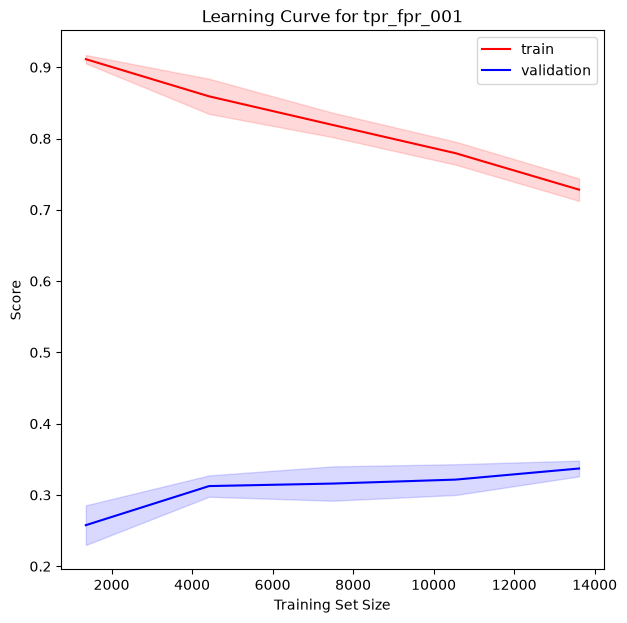

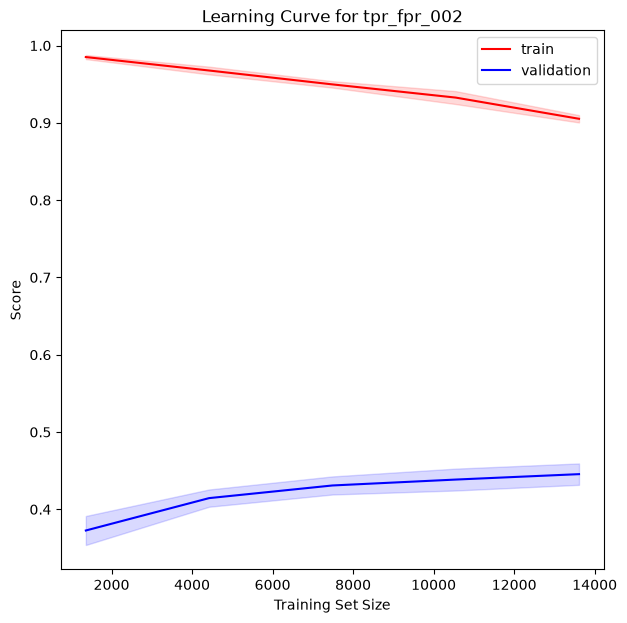

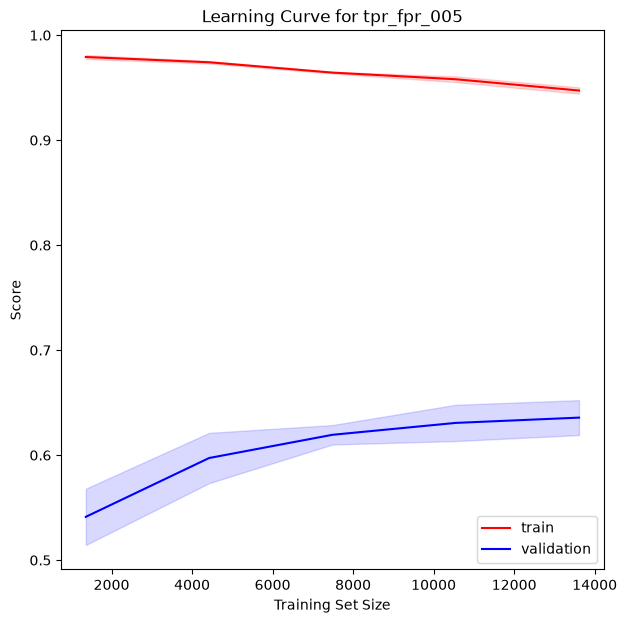

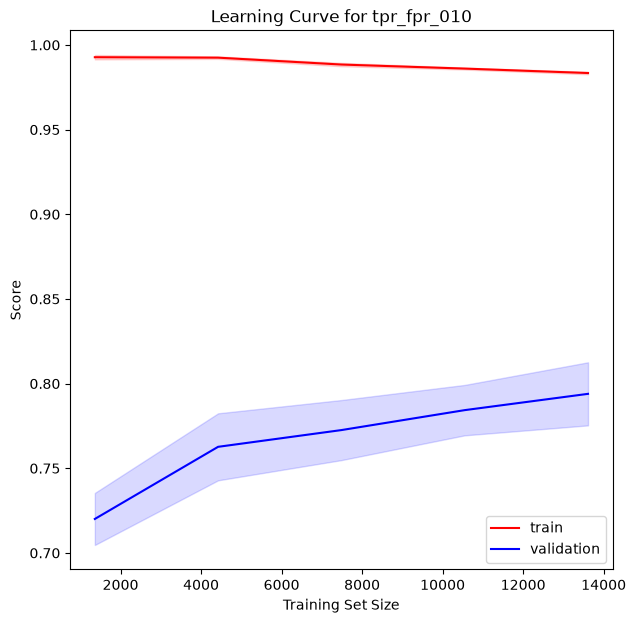

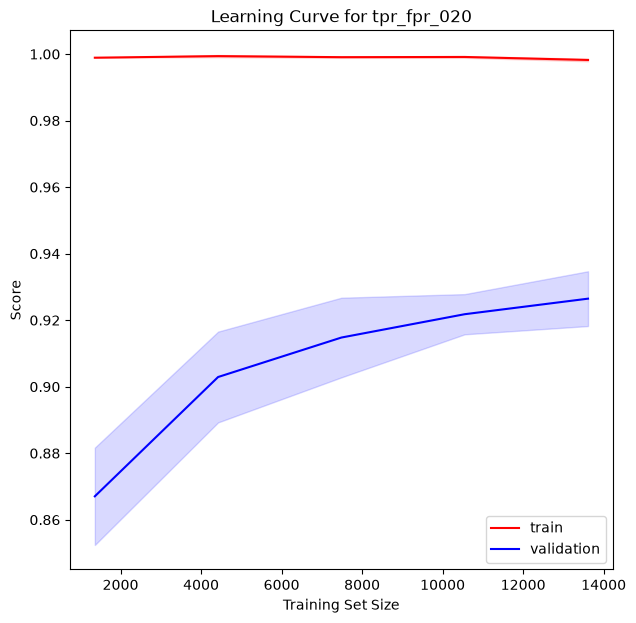

In [87]:
# plotting learning curve für best model
# computing learning curve
for scorer_name, model_path in best_model_paths.items():
    with open(model_path, "rb") as file:
        best_model = pickle.load(file)
    train_sizes, train_scores, test_scores = learning_curve(estimator=best_model, 
                                                            X=features_train_eng, 
                                                            y=np.ravel(target_train), 
                                                            cv=cv, 
                                                            scoring=scoring[scorer_name])

    # computing mean scores of train and test data
    train_mean = train_scores.mean(axis=1)
    test_mean = test_scores.mean(axis=1)

    # Standardabweichungen
    train_std = train_scores.std(axis=1)
    test_std = test_scores.std(axis=1)


    # plotting learning curve
    plt.subplots(figsize=(7,7))

    # Bereiche: Mittelwert +/- Standardabweichung
    plt.fill_between(
        train_sizes,
        train_mean - train_std,
        train_mean + train_std,
        color='red',
        alpha=0.15
    )

    plt.fill_between(
        train_sizes,
        test_mean - test_std,
        test_mean + test_std,
        color='blue',
        alpha=0.15
    )

    plt.plot(train_sizes, train_mean, label="train", color = 'red')
    plt.plot(train_sizes, test_mean, label="validation", color = 'blue')

    plt.title(f"Learning Curve for {scorer_name}")
    plt.xlabel("Training Set Size")
    plt.ylabel("Score")
    plt.legend(loc="best")

plt.show()

## Model Interpretation

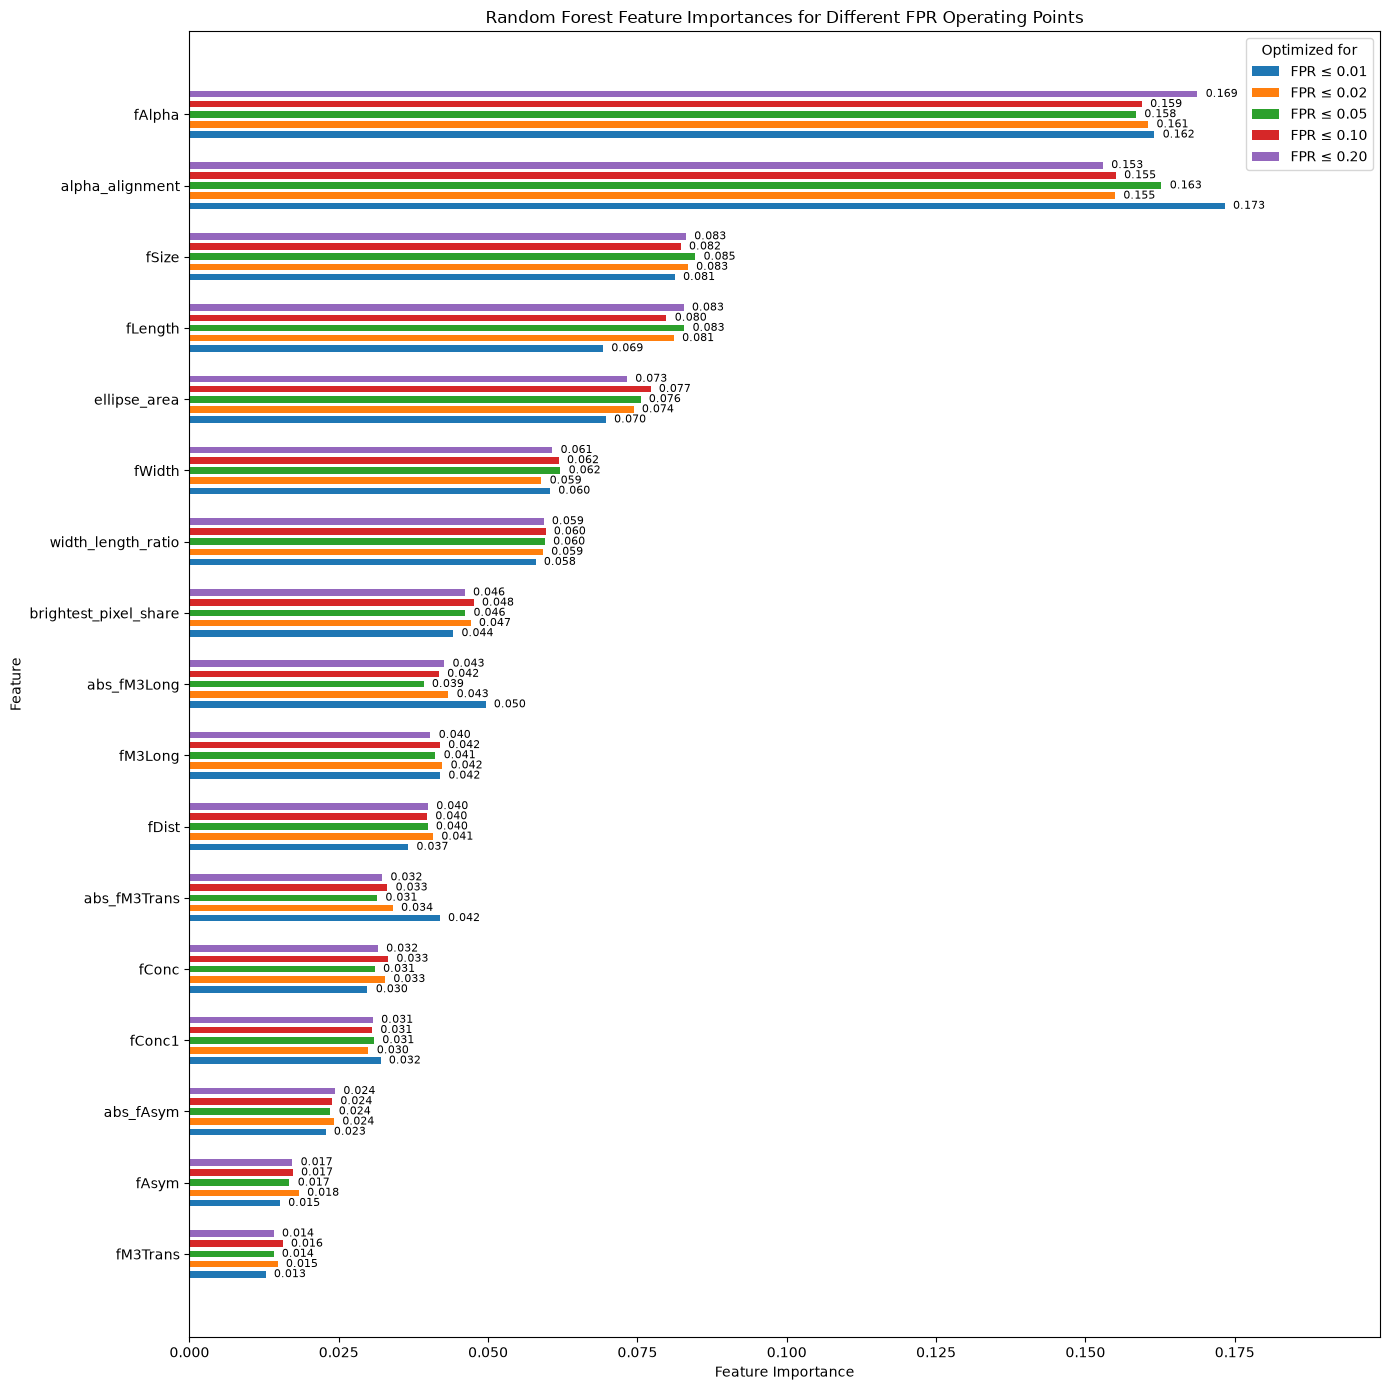

In [88]:
# nicer labels for the plot
scorer_labels = {
    "tpr_fpr_001": "FPR ≤ 0.01",
    "tpr_fpr_002": "FPR ≤ 0.02",
    "tpr_fpr_005": "FPR ≤ 0.05",
    "tpr_fpr_010": "FPR ≤ 0.10",
    "tpr_fpr_020": "FPR ≤ 0.20"
}


# dictionary for feature importances
feature_importances = {}


for scorer_name, model_path in best_model_paths.items():

    # load fitted model
    with open(model_path, "rb") as file:
        best_model = pickle.load(file)

    # get feature names
    feature_names = best_model.feature_names_in_

    # get feature importances
    importances = best_model.feature_importances_

    # store in dictionary
    feature_importances[scorer_labels[scorer_name]] = importances


# create DataFrame
importance_df = pd.DataFrame(
    feature_importances,
    index=feature_names
)


# sort features by mean importance over all models
importance_df["mean_importance"] = importance_df.mean(axis=1)

importance_df = importance_df.sort_values(
    by="mean_importance",
    ascending=True
)

# remove helper column again
importance_df = importance_df.drop(
    columns="mean_importance"
)

# number of features and models
n_features = len(importance_df)
n_models = len(importance_df.columns)

# vertical position of each feature group
feature_gap = 1.4
y = np.arange(n_features) * feature_gap

# controls bar thickness and distance between bars
bar_height = 0.13
bar_gap = 0.07

offset_step = bar_height + bar_gap

fig, ax = plt.subplots(figsize=(14, 14))


for i, column in enumerate(importance_df.columns):

    # center all bars around the feature position
    offset = (
        i - (n_models - 1) / 2
    ) * offset_step

    bars = ax.barh(
        y + offset,
        importance_df[column],
        height=bar_height,
        label=column
    )

    # show importance values
    ax.bar_label(
        bars,
        fmt="%.3f",
        padding=6,       # distance between bar and value
        fontsize=8
    )


# feature names in the center of each group
ax.set_yticks(y)
ax.set_yticklabels(importance_df.index)

ax.set_title(
    "Random Forest Feature Importances for Different FPR Operating Points"
)

ax.set_xlabel("Feature Importance")
ax.set_ylabel("Feature")

ax.legend(
    title="Optimized for"
)

# extra space on the right for the value labels
ax.set_xlim(
    0,
    importance_df.to_numpy().max() * 1.15
)

plt.tight_layout()
plt.show()




Calculating: tpr_fpr_001
Calculating: tpr_fpr_002
Calculating: tpr_fpr_005
Calculating: tpr_fpr_010
Calculating: tpr_fpr_020


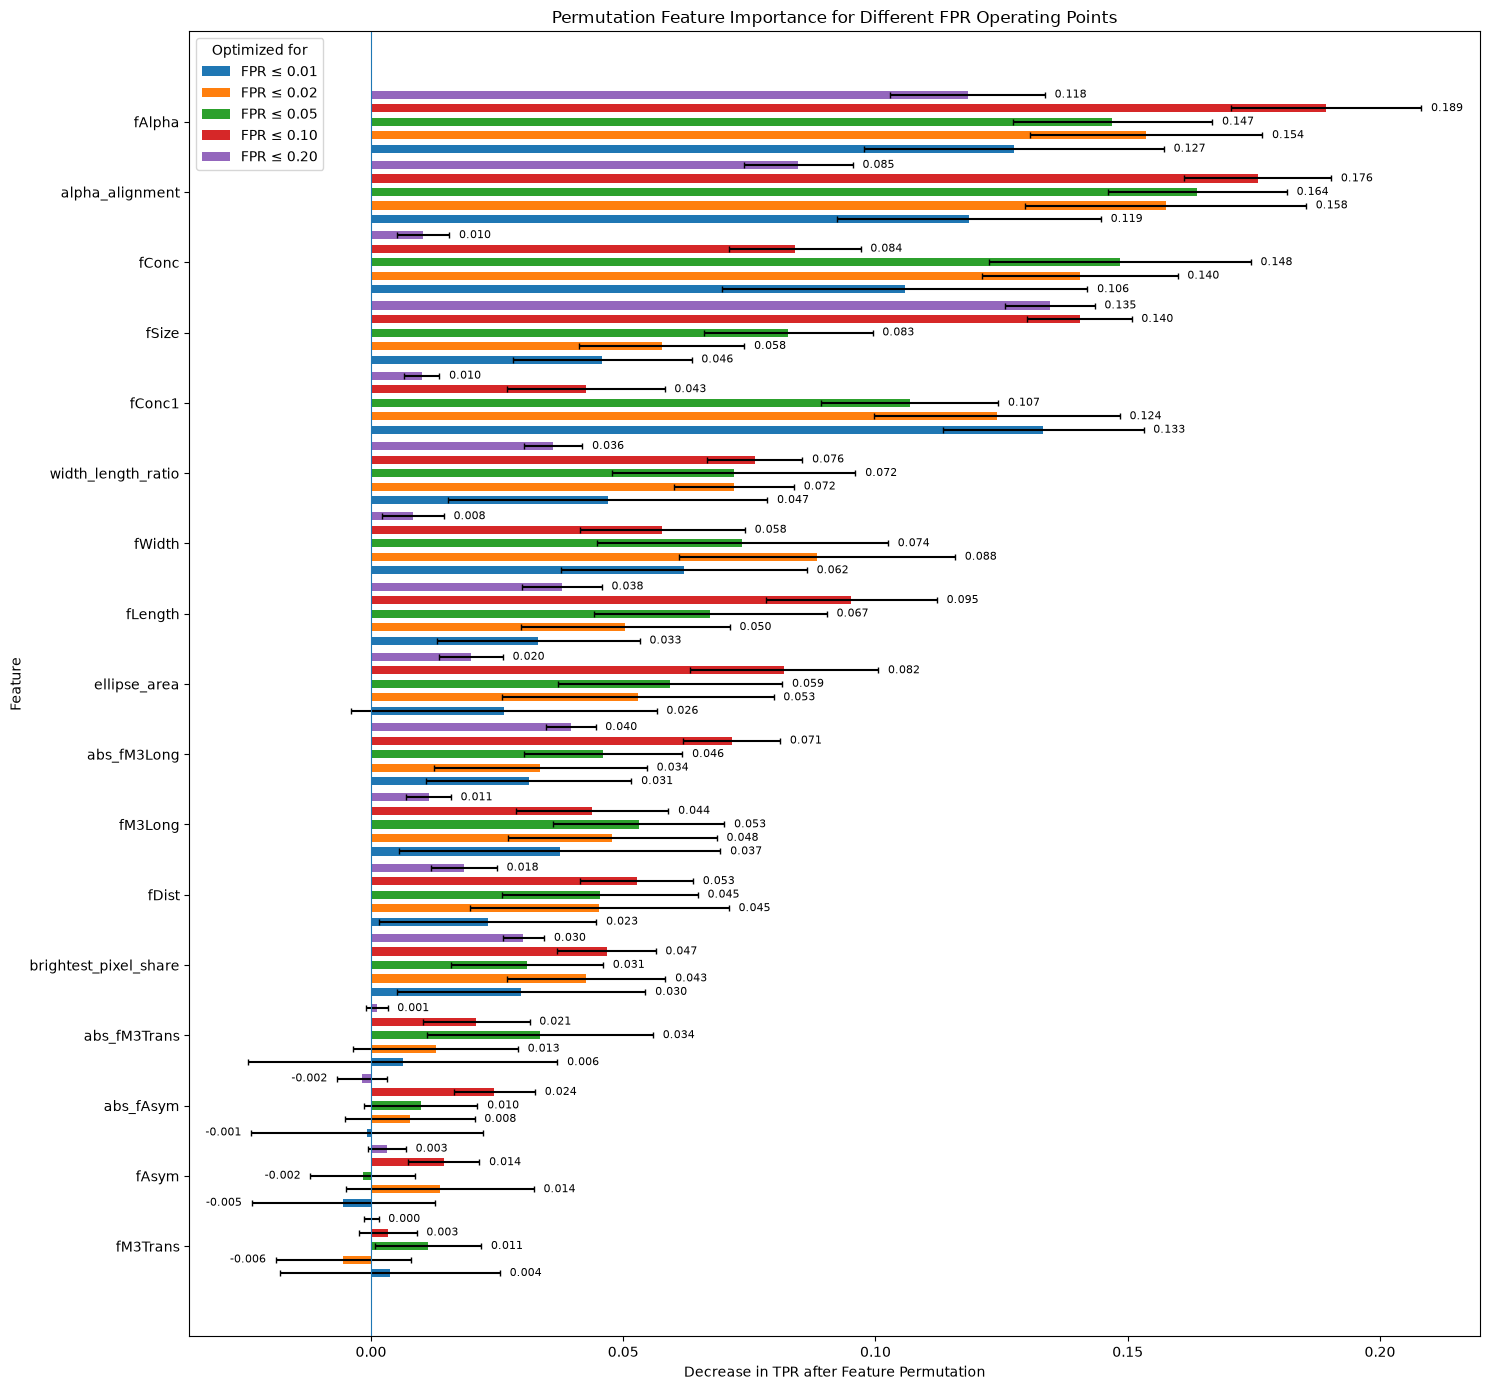

In [89]:
# Labels for plot
scorer_labels = {
    "tpr_fpr_001": "FPR ≤ 0.01",
    "tpr_fpr_002": "FPR ≤ 0.02",
    "tpr_fpr_005": "FPR ≤ 0.05",
    "tpr_fpr_010": "FPR ≤ 0.10",
    "tpr_fpr_020": "FPR ≤ 0.20"
}


# Store permutation importances
permutation_importances = {}
permutation_importances_std = {}


for scorer_name, model_path in best_model_paths.items():

    print(f"Calculating: {scorer_name}")

    # Load fitted model
    with open(model_path, "rb") as file:
        best_model = pickle.load(file)

    # Calculate permutation feature importance
    result = permutation_importance(
        estimator=best_model,
        X=features_test_eng,
        y=target_test,
        scoring=scoring[scorer_name],
        n_repeats=20,
        random_state=42,
        n_jobs=1
    )

    permutation_importances[
        scorer_labels[scorer_name]
    ] = result.importances_mean

    permutation_importances_std[
        scorer_labels[scorer_name]
    ] = result.importances_std
    
importance_df = pd.DataFrame(
    permutation_importances,
    index=features_test_eng.columns
)

importance_std_df = pd.DataFrame(
    permutation_importances_std,
    index=features_test_eng.columns
)

feature_order = (
    importance_df
    .mean(axis=1)
    .sort_values(ascending=True)
    .index
)

importance_df = importance_df.loc[feature_order]
importance_std_df = importance_std_df.loc[feature_order]

# Number of features and models
n_features = len(importance_df)
n_models = len(importance_df.columns)

# Spacing
feature_gap = 1.3
bar_height = 0.15
bar_gap = 0.1

y = np.arange(n_features) * feature_gap

offset_step = bar_height + bar_gap


fig, ax = plt.subplots(figsize=(15, 14))


for i, column in enumerate(importance_df.columns):

    offset = (
        i - (n_models - 1) / 2
    ) * offset_step

    bars = ax.barh(
        y + offset,
        importance_df[column],
        height=bar_height,
        xerr=importance_std_df[column],
        label=column,
        capsize=2
    )

    # Add values to bars
    ax.bar_label(
        bars,
        fmt="%.3f",
        padding=7,
        fontsize=8
    )


# Feature names in center of each group
ax.set_yticks(y)
ax.set_yticklabels(importance_df.index)

ax.set_title(
    "Permutation Feature Importance for Different FPR Operating Points"
)

ax.set_xlabel(
    "Decrease in TPR after Feature Permutation"
)

ax.set_ylabel(
    "Feature"
)

ax.legend(
    title="Optimized for"
)

# Vertical zero line
ax.axvline(
    x=0,
    linewidth=0.8
)

plt.tight_layout()
plt.show()